# Latin America Air Quality - ML Pipeline

This notebook **dynamically loads every CSV** that the daily fetcher drops into
`daily_updates/`, runs a full
preprocessing and feature-engineering pass, audits & repairs missing data, and
finally trains **course-approved Machine Learning models** to predict
the **Air Quality Category** (Good · Moderate · Poor · Hazardous).

**Models evaluated:**
- Random Forest (Ensemble/Bagging)
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Decision Tree (J48 equivalent)
- Logistic Regression
- Naive Bayes (Gaussian)
- AdaBoost (Boosting Ensemble)
- Bagging Classifier (Bagging Ensemble)

## 0 · Environment & Imports

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
from datetime import datetime
import math

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.impute import KNNImputer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print("  All imports loaded successfully")

  All imports loaded successfully


---
## 1 · Dynamic Data Ingestion

We scan the `daily_updates/` folder for **every** CSV and concatenate them.
The base historical dataset was removed due to column mismatch.

In [2]:
# ---------- paths (relative to project root) ----------
PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__"))
DAILY_DIR    = os.path.join(PROJECT_ROOT, "daily_updates")

# ---------- 1a. load daily updates ----------
csv_files = sorted(glob.glob(os.path.join(DAILY_DIR, "*.csv")))
print(f"  Found {len(csv_files)} daily-update files in daily_updates/")

daily_frames = []
for fp in csv_files:
    try:
        tmp = pd.read_csv(fp)
        # Extract date from filename: daily_update_air_quality_YYYY-MM-DD.csv
        basename = os.path.basename(fp)
        date_str = basename.replace("daily_update_air_quality_", "").replace(".csv", "")
        tmp["File_Date"] = pd.to_datetime(date_str, errors="coerce")
        daily_frames.append(tmp)
    except Exception as e:
        print(f"     Skipped {os.path.basename(fp)}: {e}")

df_raw = pd.concat(daily_frames, ignore_index=True) if daily_frames else pd.DataFrame()
print(f"\n  Total raw rows from daily updates: {len(df_raw):,}")
print(f"   Columns: {list(df_raw.columns)}")

# Drop non-Latin outliers (Spain & India) as requested
# Data had mislabelled 'Country' strings (e.g., India labeled as Peru), 
# so we filter strictly using string matching on the City column instead.
if "City" in df_raw.columns:
    df_raw = df_raw[~df_raw["City"].str.contains("Spain|India", case=False, na=False)]
    print(f"  Dropped Spain & India. Rows remaining: {len(df_raw):,}")

  Found 180 daily-update files in daily_updates/



  Total raw rows from daily updates: 12,642
   Columns: ['City', 'Country', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'AQI', 'Air_Quality_Category', 'Population_Density', 'Proximity_to_Industrial_Areas', 'Timestamp', 'File_Date']
  Dropped Spain & India. Rows remaining: 12,102


---
## 2 · Initial Data Audit

Before touching anything, let's understand exactly what we're working with:
shape, dtypes, missing counts, duplicate rows, and basic statistics.

In [3]:
print("=" * 60)
print("SHAPE:", df_raw.shape)
print("=" * 60)
df_raw.info()

SHAPE: (12102, 17)
<class 'pandas.core.frame.DataFrame'>
Index: 12102 entries, 0 to 12640
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   City                           12102 non-null  object        
 1   Country                        12102 non-null  object        
 2   Latitude                       12102 non-null  float64       
 3   Longitude                      12102 non-null  float64       
 4   Temperature                    12051 non-null  float64       
 5   Humidity                       12051 non-null  float64       
 6   PM2.5                          9663 non-null   float64       
 7   PM10                           7192 non-null   float64       
 8   NO2                            6898 non-null   float64       
 9   SO2                            6559 non-null   float64       
 10  CO                             6919 non-null   float64       
 11  A

In [4]:
# Missing values — absolute + percentage
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct,
    "Dtype": df_raw.dtypes
}).sort_values("Missing %", ascending=False)
print("\n  Missing-data report (sorted by % missing):\n")
print(miss_report.to_string())


  Missing-data report (sorted by % missing):

                               Missing Count  Missing %           Dtype
Proximity_to_Industrial_Areas           7296      60.29         float64
Population_Density                      7122      58.85         float64
SO2                                     5543      45.80         float64
NO2                                     5204      43.00         float64
CO                                      5183      42.83         float64
PM10                                    4910      40.57         float64
PM2.5                                   2439      20.15         float64
Air_Quality_Category                    1446      11.95          object
Temperature                               51       0.42         float64
Humidity                                  51       0.42         float64
City                                       0       0.00          object
Longitude                                  0       0.00         float64
Country          

In [5]:
# Duplicate check
n_dups = df_raw.duplicated().sum()
print(f"\n  Exact duplicate rows: {n_dups}")
if n_dups > 0:
    df_raw.drop_duplicates(inplace=True)
    print(f"  Dropped duplicates. New shape: {df_raw.shape}")


  Exact duplicate rows: 0


In [6]:
# Descriptive statistics for numerics
df_raw.describe().T

,count,mean,min,25%,50%,75%,max,std
Latitude,12102.0,-7.514317,-53.158295,-29.97039,-2.897,4.78374,32.640028,20.589087
Longitude,12102.0,-78.672196,-115.474639,-79.003,-76.97093,-71.678261,-58.342538,12.288392
Temperature,12051.0,19.55229,-4.0,15.0,20.2,23.8,62.35,5.63817
Humidity,12051.0,66.190507,4.0,53.0,72.0,84.0,100.0,22.21999
PM2.5,9663.0,76.827176,1.0,46.0,64.0,91.0,967.0,59.656999
PM10,7192.0,48.947303,1.0,25.0,41.0,55.0,999.0,52.001162
NO2,6898.0,21.056408,0.1,8.4,13.4,20.2,130.2,27.581855
SO2,6559.0,6.502531,0.1,1.5,4.0,7.8,433.7,12.191436
CO,6919.0,16.991588,0.1,4.9,8.9,14.3,500.0,39.751061
Population_Density,4980.0,19859.549512,165.52,1713.54,4363.1,31197.09,127188.7,32570.697198


---
## 3 · Data Cleaning & Missing-Value Repair

**Strategy:**

| Column | Repair Method |
|--------|--------------|
| `Timestamp` | Parse to datetime; fill missing with file-name date or drop |
| `City`, `Country` | Fill with `"Unknown"` (non-predictive, used for grouping only) |
| `AQI` | Derive from `PM2.5` if missing, or median-impute by category |
| `Air_Quality_Category` | Derive from `AQI` if missing |
| Numeric sensors (`PM2.5 PM10 NO2 SO2 CO Temperature Humidity`) | KNN-impute within station clusters |
| `Population_Density`, `Proximity_to_Industrial_Areas` | Median-impute by Country |
| `Latitude`, `Longitude` | Fill from same City if available, else drop |

In [7]:
df = df_raw.copy()

# ---------- 3a. Timestamp ----------
if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# ---------- 3b. City / Country ----------
df["City"]    = df["City"].fillna("Unknown")
df["Country"] = df["Country"].fillna("Unknown")

# ---------- 3c. City-level Constants (Lat, Lon, Proximity, Population) ----------
# Latitude, Longitude, and Proximity do not change for a given city.
# Find all rows for a city and fill missing values using the exact same known values.
if "City" in df.columns:
    for col in ["Latitude", "Longitude", "Proximity_to_Industrial_Areas", "Population_Density"]:
        if col in df.columns:
            df[col] = df.groupby("City")[col].transform(lambda s: s.fillna(s.median()))

# ---------- 3d. AQI / Air_Quality_Category cross-repair ----------
# Coerce AQI to numeric first — daily CSVs may have string artifacts like "-"
if "AQI" in df.columns:
    df["AQI"] = pd.to_numeric(df["AQI"], errors="coerce")

def categorize_aqi(aqi):
    """Same logic used by the fetcher script."""
    if pd.isna(aqi):
        return np.nan
    aqi = float(aqi)
    if aqi <= 50:
        return "Good"
    if aqi <= 100:
        return "Moderate"
    if aqi <= 250:
        return "Poor"
    return "Hazardous"

# If AQI exists but category is missing → derive it
if "AQI" in df.columns:
    mask_no_cat = df["Air_Quality_Category"].isna() | (df["Air_Quality_Category"] == "")
    df.loc[mask_no_cat, "Air_Quality_Category"] = df.loc[mask_no_cat, "AQI"].apply(categorize_aqi)

# If PM2.5 exists but AQI is missing → approximate AQI ≈ PM2.5 (US EPA breakpoints simplified)
if "AQI" in df.columns and "PM2.5" in df.columns:
    mask_no_aqi = df["AQI"].isna()
    df.loc[mask_no_aqi, "AQI"] = pd.to_numeric(df.loc[mask_no_aqi, "PM2.5"], errors="coerce")
    # Re-derive category for newly filled AQI
    still_no_cat = df["Air_Quality_Category"].isna() | (df["Air_Quality_Category"] == "")
    df.loc[still_no_cat, "Air_Quality_Category"] = df.loc[still_no_cat, "AQI"].apply(categorize_aqi)

# ---------- 3e. Sensor numerics — KNN imputation ----------
sensor_cols = ["Temperature", "Humidity", "PM2.5", "PM10", "NO2", "SO2", "CO"]
existing_sensor_cols = [c for c in sensor_cols if c in df.columns]

if existing_sensor_cols:
    print(f"  KNN-imputing sensor columns: {existing_sensor_cols}")
    imputer = KNNImputer(n_neighbors=5)
    df[existing_sensor_cols] = imputer.fit_transform(df[existing_sensor_cols])

# ---------- 3f. Fallback for unresolvable location data ----------
# For any remaining missing data where we can not do anything (i.e. no known city data),
# we retain the previous fallback safety net to prevent dropping the entire base dataset.
for col in ["Population_Density", "Proximity_to_Industrial_Areas"]:
    if col in df.columns:
        df[col] = df.groupby("Country")[col].transform(lambda s: s.fillna(s.median()))
        df[col].fillna(df[col].median(), inplace=True)

# ---------- 3g. Drop rows still missing target ----------
before = len(df)
df = df.dropna(subset=["Air_Quality_Category"])
df = df[df["Air_Quality_Category"] != ""]
after = len(df)
print(f"\n️  Dropped {before - after} rows with no target label")
print(f"   Remaining rows: {after:,}")

  KNN-imputing sensor columns: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO']



️  Dropped 1264 rows with no target label
   Remaining rows: 10,838


In [8]:
# Post-cleaning missing report
missing2 = df.isnull().sum()
missing2_pct = (missing2 / len(df) * 100).round(2)
miss_report2 = pd.DataFrame({
    "Missing Count": missing2,
    "Missing %": missing2_pct
}).sort_values("Missing %", ascending=False)
print("\n  Post-cleaning missing-data report:\n")
print(miss_report2[miss_report2["Missing Count"] > 0].to_string()
      if miss_report2["Missing Count"].sum() > 0
      else "   No missing values remain in any column!")


  Post-cleaning missing-data report:

   No missing values remain in any column!


---
## 4 · Feature Engineering

We create several new features to help the model:

- **Temporal**: day of week, month, hour, weekend flag, season
- **Pollutant ratios**: PM2.5/PM10, NO2/SO2, CO/NO2
- **Pollutant index**: composite pollution score (sum of z-scores)
- **Geo buckets**: latitude bands (Tropical / Subtropical / Temperate)
- **AQI per capita**: AQI normalized by population density (pollution load)

In [9]:
# ---------- 4a. Temporal features ----------
# Use the date extracted from the filename as the primary temporal source
if "File_Date" in df.columns and df["File_Date"].notna().any():
    ts_date = df["File_Date"]
    df["DayOfWeek"]  = ts_date.dt.dayofweek          # 0=Mon … 6=Sun
    df["Month"]      = ts_date.dt.month
    df["IsWeekend"]  = (ts_date.dt.dayofweek >= 5).astype(int)

    # Season for Southern + Northern hemispheres (simplified: by month)
    def month_to_season(m):
        if pd.isna(m):
            return np.nan
        if m in [12, 1, 2]:
            return 0  # DJF
        if m in [3, 4, 5]:
            return 1  # MAM
        if m in [6, 7, 8]:
            return 2  # JJA
        return 3      # SON

    df["Season"] = ts_date.dt.month.apply(month_to_season)
    print("  Temporal features created from filename: DayOfWeek, Month, IsWeekend, Season")
    
    # Try to extract Hour from internal Timestamp if available
    if "Timestamp" in df.columns and df["Timestamp"].notna().any():
        df["Hour"] = df["Timestamp"].dt.hour
        print("  Hour feature extracted from Timestamp column")
    else:
        df["Hour"] = 0
else:
    print("  No File_Date found — skipping temporal features.")

# ---------- 4b. Pollutant ratios ----------
if "PM2.5" in df.columns and "PM10" in df.columns:
    df["PM25_PM10_Ratio"] = (df["PM2.5"] / df["PM10"].replace(0, np.nan)).fillna(0)

if "NO2" in df.columns and "SO2" in df.columns:
    df["NO2_SO2_Ratio"]   = (df["NO2"]  / df["SO2"].replace(0, np.nan)).fillna(0)

if "CO" in df.columns and "NO2" in df.columns:
    df["CO_NO2_Ratio"]    = (df["CO"]   / df["NO2"].replace(0, np.nan)).fillna(0)

print("  Pollutant ratio features created")

# ---------- 4c. Composite pollution score ----------
poll_cols = [c for c in ["PM2.5", "PM10", "NO2", "SO2", "CO"] if c in df.columns]
if poll_cols:
    from scipy import stats as sp_stats
    poll_z = df[poll_cols].apply(sp_stats.zscore, nan_policy="omit")
    df["Pollution_Index"] = poll_z.mean(axis=1)
    print("  Pollution_Index (mean z-score of pollutants) created")

# ---------- 4d. Geo bucket ----------
if "Latitude" in df.columns:
    def lat_band(lat):
        if pd.isna(lat):
            return np.nan
        abs_lat = abs(lat)
        if abs_lat <= 23.5:
            return 0  # Tropical
        if abs_lat <= 35:
            return 1  # Subtropical
        return 2      # Temperate

    df["Lat_Band"] = df["Latitude"].apply(lat_band)
    print("  Lat_Band (Tropical/Subtropical/Temperate) created")

# ---------- 4e. AQI per capita ----------
if "AQI" in df.columns and "Population_Density" in df.columns:
    df["AQI_Per_Capita"] = (
        df["AQI"] / df["Population_Density"].replace(0, np.nan)
    ).fillna(0)
    print("  AQI_Per_Capita created")

# ---------- 4f. Temperature × Humidity interaction ----------
if "Temperature" in df.columns and "Humidity" in df.columns:
    df["Temp_Humidity"] = df["Temperature"] * df["Humidity"]
    print("️  Temp × Humidity interaction created")

print(f"\n️  Final engineered shape: {df.shape}")
df.tail(10)

  Temporal features created from filename: DayOfWeek, Month, IsWeekend, Season
  Hour feature extracted from Timestamp column
  Pollutant ratio features created
  Pollution_Index (mean z-score of pollutants) created
  Lat_Band (Tropical/Subtropical/Temperate) created
  AQI_Per_Capita created
️  Temp × Humidity interaction created

️  Final engineered shape: (10838, 29)


,City,Country,Latitude,Longitude,Temperature,Humidity,PM2.5,PM10,NO2,SO2,...,IsWeekend,Season,Hour,PM25_PM10_Ratio,NO2_SO2_Ratio,CO_NO2_Ratio,Pollution_Index,Lat_Band,AQI_Per_Capita,Temp_Humidity
12626,"Valdivia, Chile",Chile,-39.831316,-73.228513,10.2,93.0,392.0,249.0,29.44,4.60,...,1,2,2,1.574297,6.400000,2.133152,2.311829,2,0.205185,948.60
12627,"Osorno, Chile",Chile,-40.584479,-73.118720,10.2,93.0,316.0,158.0,19.70,15.56,...,1,2,2,2.000000,1.266067,0.696447,1.496868,2,0.168073,948.60
12628,"Coyhaique, Chile",Chile,-45.579964,-72.061126,0.0,92.0,312.0,175.0,34.70,15.56,...,1,2,2,1.782857,2.230077,0.515850,1.715078,2,0.493374,0.00
12629,"La Union, Chile",Chile,-40.286857,-73.076710,10.2,93.0,261.0,140.2,19.88,7.34,...,1,2,2,1.861626,2.708447,0.875252,1.083813,2,0.773036,948.60
12630,"Rancagua I, Chile",Chile,-34.162315,-70.713919,10.2,92.7,165.0,85.0,18.10,1.50,...,1,2,2,1.941176,12.066667,0.066298,0.279011,1,0.056010,945.54
12631,"Rengo, Chile",Chile,-34.394541,-70.852982,10.4,92.2,163.0,76.0,18.16,6.44,...,1,2,2,2.144737,2.819876,0.635463,0.389444,1,0.339385,958.88
12632,"Balneario Curanilahue, Chile",Chile,-37.485132,-73.331626,13.0,87.0,160.0,79.0,30.50,8.54,...,1,2,2,2.025316,3.571429,0.458361,0.556856,2,0.416949,1131.00
12633,"Rancagua II, Chile",Chile,-34.143888,-70.737131,10.1,92.8,160.0,71.0,17.66,6.40,...,1,2,2,2.253521,2.759375,0.828992,0.368742,1,0.054313,937.28
12634,"Padre Las Casas II, Chile",Chile,-38.764767,-72.598796,11.5,100.0,160.0,69.0,12.10,5.36,...,1,2,2,2.318841,2.257463,0.644628,0.251522,2,0.053358,1150.00
12635,"US Embassy, Buenos Aires, Argentina",Argentina,-34.577300,-58.417600,25.0,72.9,5.0,36.4,13.74,8.02,...,1,2,2,0.137363,1.713217,0.937409,-0.333694,1,0.000126,1822.50


---
## 5 · Exploratory Visualizations (Post-Engineering)

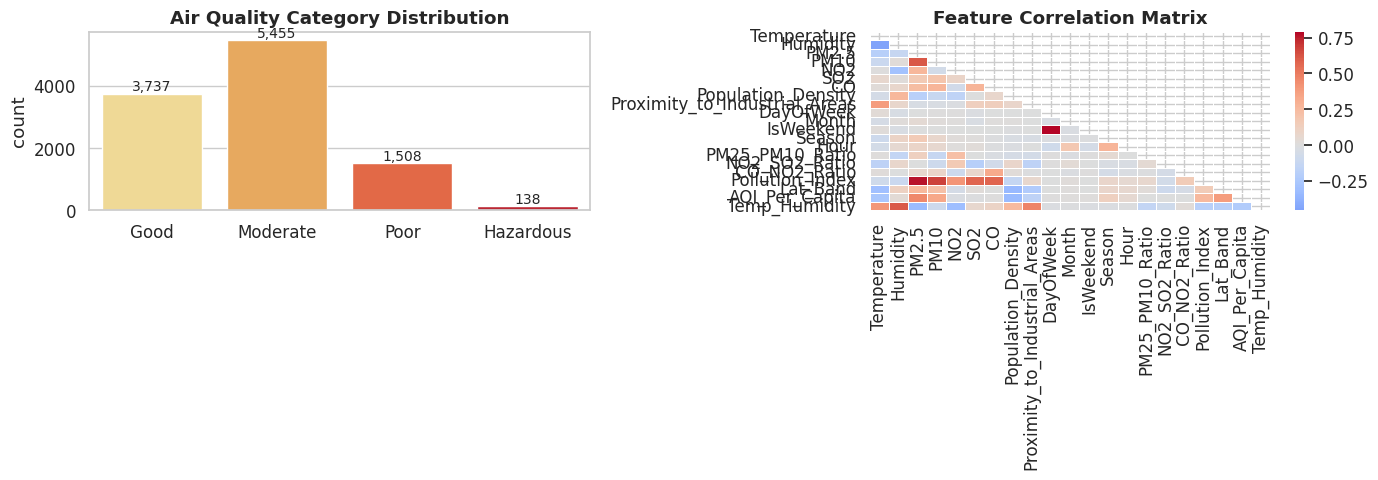

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 5a — Class distribution
order = ["Good", "Moderate", "Poor", "Hazardous"]
existing_order = [c for c in order if c in df["Air_Quality_Category"].unique()]
sns.countplot(data=df, x="Air_Quality_Category", order=existing_order,
              palette="YlOrRd", ax=axes[0])
axes[0].set_title("Air Quality Category Distribution", fontweight="bold")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha="center", va="bottom", fontsize=10)

# 5b — Correlation heatmap of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude lat/lon/AQI (leaky) from the heatmap
exclude = ["Latitude", "Longitude", "AQI"]
heat_cols = [c for c in numeric_cols if c not in exclude]
corr = df[heat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, linewidths=.5,
            annot=False, ax=axes[1])
axes[1].set_title("Feature Correlation Matrix", fontweight="bold")

plt.tight_layout()
plt.show()

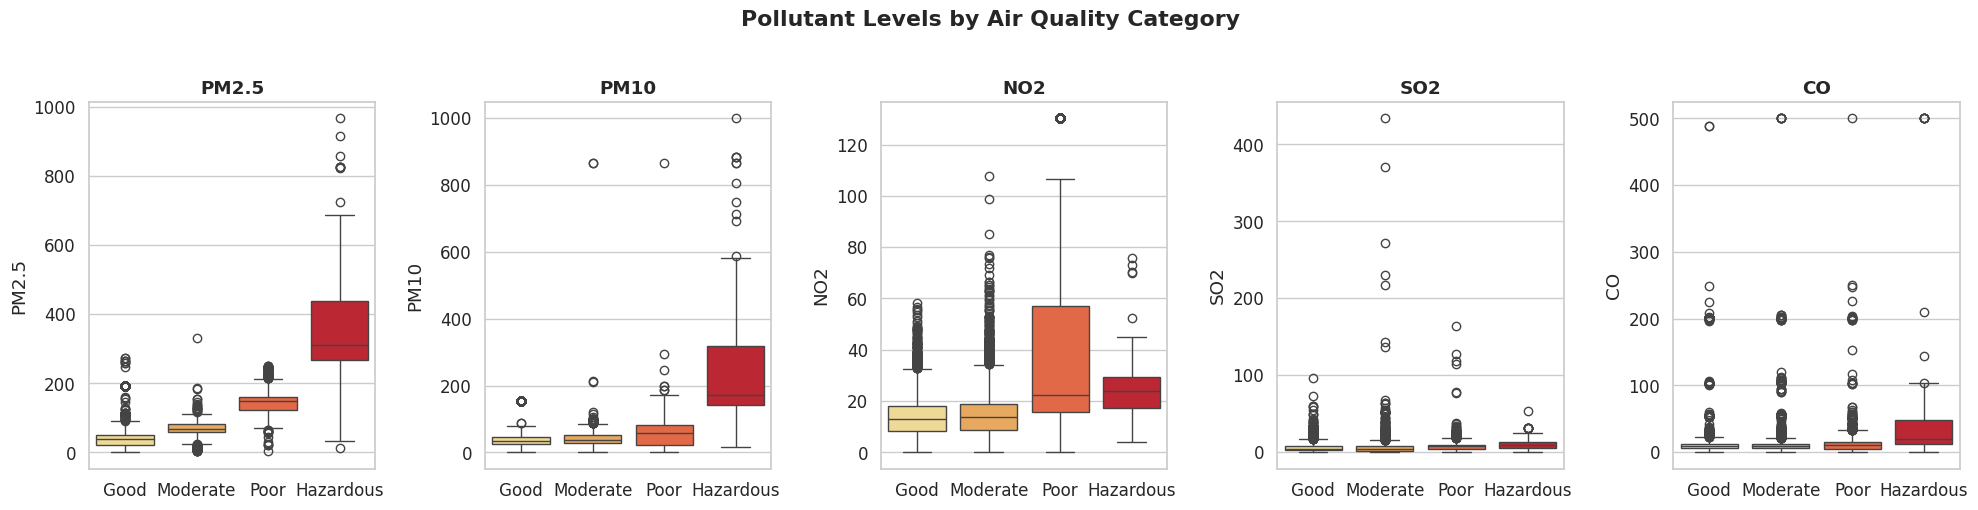

In [11]:
# Box-plots of key sensors by category
sensor_plot = [c for c in ["PM2.5", "PM10", "NO2", "SO2", "CO"] if c in df.columns]
fig, axes = plt.subplots(1, len(sensor_plot), figsize=(4 * len(sensor_plot), 5), sharey=False)
if len(sensor_plot) == 1:
    axes = [axes]
for ax, col in zip(axes, sensor_plot):
    sns.boxplot(data=df, x="Air_Quality_Category", y=col,
                order=existing_order, palette="YlOrRd", ax=ax)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
plt.suptitle("Pollutant Levels by Air Quality Category", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

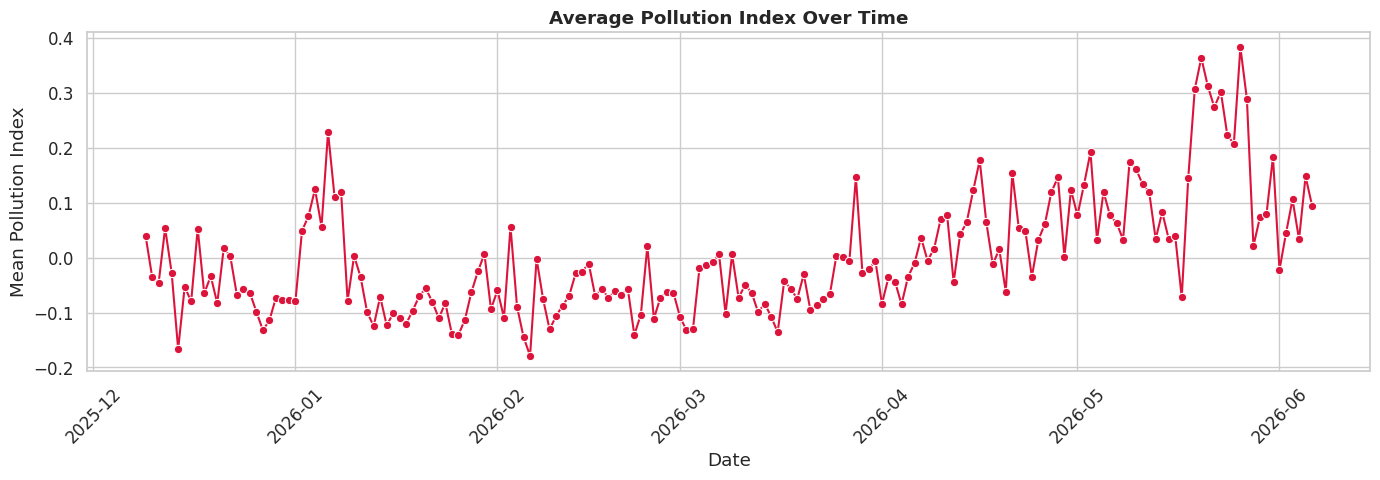

In [12]:
# 5c — Time Series Trend (if File_Date exists)
if "File_Date" in df.columns and df["File_Date"].notna().any():
    plt.figure(figsize=(14, 5))
    df_time = df.groupby("File_Date")["Pollution_Index"].mean().reset_index()
    sns.lineplot(data=df_time, x="File_Date", y="Pollution_Index", marker="o", color="crimson")
    plt.title("Average Pollution Index Over Time", fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Mean Pollution Index")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

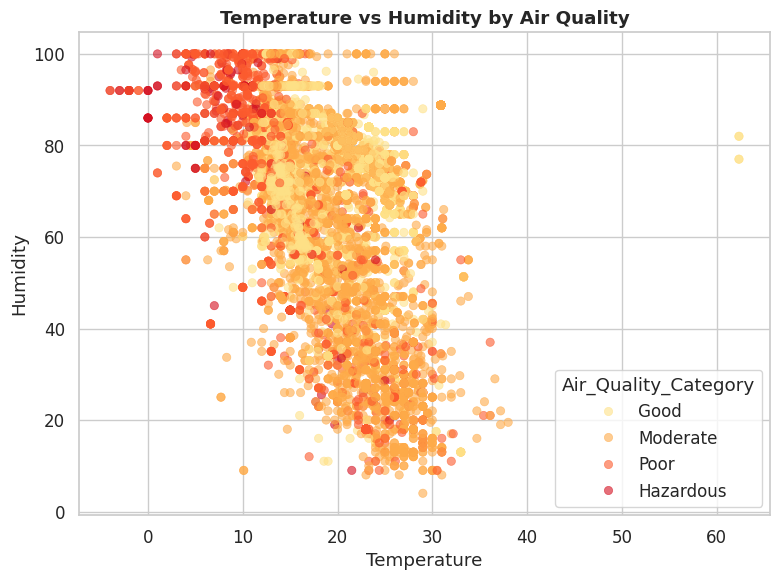

In [13]:
# 5d — Temperature vs Humidity interaction
if "Temperature" in df.columns and "Humidity" in df.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="Temperature", y="Humidity", hue="Air_Quality_Category", 
                    hue_order=existing_order, palette="YlOrRd", alpha=0.6, edgecolor=None)
    plt.title("Temperature vs Humidity by Air Quality", fontweight="bold")
    plt.tight_layout()
    plt.show()

In [14]:
# 5e — Interactive Global Air Quality Map (Plotly)
if "Latitude" in df.columns and "Longitude" in df.columns:
    import plotly.express as px
    
    # We use a static copy of the data to avoid modifying the original dataframe
    # size_col needs to be purely numeric and positive
    plot_df = df.copy()
    if "AQI" in plot_df.columns:
        # Scale AQI slightly so bubbles aren't massive, ensure minimum size
        plot_df["Bubble_Size"] = plot_df["AQI"].clip(lower=1)
    else:
        plot_df["Bubble_Size"] = 10
        
    hover_cols = ["PM2.5", "PM10", "Temperature"]
    hover_cols = [c for c in hover_cols if c in plot_df.columns]
    
    fig_map = px.scatter_mapbox(
        plot_df, 
        lat="Latitude", 
        lon="Longitude", 
        color="Air_Quality_Category",
        size="Bubble_Size",
        hover_name="City" if "City" in plot_df.columns else None,
        hover_data=hover_cols,
        color_discrete_map={
            "Good": "#00b050",      # Green
            "Moderate": "#ffc000",  # Yellow
            "Poor": "#7030a0",      # Red
            "Hazardous": "#ff0000"  # Purple
        },
        category_orders={"Air_Quality_Category": ["Good", "Moderate", "Poor", "Hazardous"]},
        zoom=1.5,
        mapbox_style="carto-positron",
        title="Interactive Global Air Quality Map (Hover for details)"
    )
    
    fig_map.update_layout(
        margin={"r": 0, "t": 40, "l": 0, "b": 0},
        title_font=dict(size=18, family="Arial", color="black")
    )
    fig_map.show()

---
## 6 · Prepare Features & Target for Modeling

In [15]:
# ---------- encode target ----------
le = LabelEncoder()
df["Target"] = le.fit_transform(df["Air_Quality_Category"])
print("️  Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ---------- select feature columns ----------
# Drop non-predictive / leaky columns
drop_cols = [
    "City", "Country", "Timestamp", "File_Date", "Air_Quality_Category", "Target",
    "AQI",       # leaky — directly determines category - MAIN POINT HERE, if not MODEL WILL CHEAT
    "Latitude", "Longitude"  # raw coords replaced by Lat_Band
]
feature_cols = [c for c in df.columns if c not in drop_cols
                and df[c].dtype in [np.float64, np.int64, np.float32, np.int32]]
print(f"  Feature columns ({len(feature_cols)}):\n   {feature_cols}")

X = df[feature_cols].copy()
y = df["Target"].copy()

# ---------- final NaN safety net ----------
remaining_nan = X.isnull().sum().sum()
if remaining_nan > 0:
    print(f"  {remaining_nan} NaN values remain in features — filling with column medians")
    X.fillna(X.median(), inplace=True)

print(f"\n  X shape: {X.shape}  |  y shape: {y.shape}")
print(f"   Class balance:\n{y.value_counts().rename(index=dict(zip(le.transform(le.classes_), le.classes_)))}")

️  Label mapping: {'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Poor': np.int64(3)}
  Feature columns (21):
   ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Population_Density', 'Proximity_to_Industrial_Areas', 'DayOfWeek', 'Month', 'IsWeekend', 'Season', 'Hour', 'PM25_PM10_Ratio', 'NO2_SO2_Ratio', 'CO_NO2_Ratio', 'Pollution_Index', 'Lat_Band', 'AQI_Per_Capita', 'Temp_Humidity']

  X shape: (10838, 21)  |  y shape: (10838,)
   Class balance:
Target
Moderate     5455
Good         3737
Poor         1508
Hazardous     138
Name: count, dtype: int64


---
## 7 · Train / Test Split & Scaling

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

  Train: 8,670  |  Test: 2,168


---
## 8 · Baseline Model Training

We train all 8 models first to establish a baseline.

In [17]:
results_base = {}
preds_map_base = {}

models_to_train = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, class_weight="balanced", random_state=42, n_jobs=-1),
    "SVM": SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=15, class_weight="balanced", random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Bagging": BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1)
}

for name, model in models_to_train.items():
    print("=" * 50)
    print(f" Training Baseline {name}...")
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    results_base[name] = {"Accuracy": acc, "Macro F1": f1, "model": model}
    preds_map_base[name] = y_pred
    
    print(f" {name}  —  Acc: {acc:.4f}  |  F1: {f1:.4f}")

 Training Baseline Random Forest...


 Random Forest  —  Acc: 0.9903  |  F1: 0.9823
 Training Baseline SVM...


 SVM  —  Acc: 0.9022  |  F1: 0.8927
 Training Baseline KNN...
 KNN  —  Acc: 0.8552  |  F1: 0.8332
 Training Baseline Decision Tree...
 Decision Tree  —  Acc: 0.9917  |  F1: 0.9752
 Training Baseline Logistic Regression...


 Logistic Regression  —  Acc: 0.7482  |  F1: 0.7811
 Training Baseline Naive Bayes...
 Naive Bayes  —  Acc: 0.6697  |  F1: 0.6625
 Training Baseline AdaBoost...


 AdaBoost  —  Acc: 0.9437  |  F1: 0.9125
 Training Baseline Bagging...


 Bagging  —  Acc: 0.9931  |  F1: 0.9805


---
## 9 · Baseline Model Comparison


Baseline Model Comparison:
                     Accuracy  Macro F1
Random Forest        0.990314  0.982346
Bagging              0.993081  0.980539
Decision Tree        0.991697  0.975203
AdaBoost             0.943727  0.912531
SVM                  0.902214  0.892749
KNN                  0.855166  0.833205
Logistic Regression  0.748155  0.781058
Naive Bayes          0.669742  0.662508


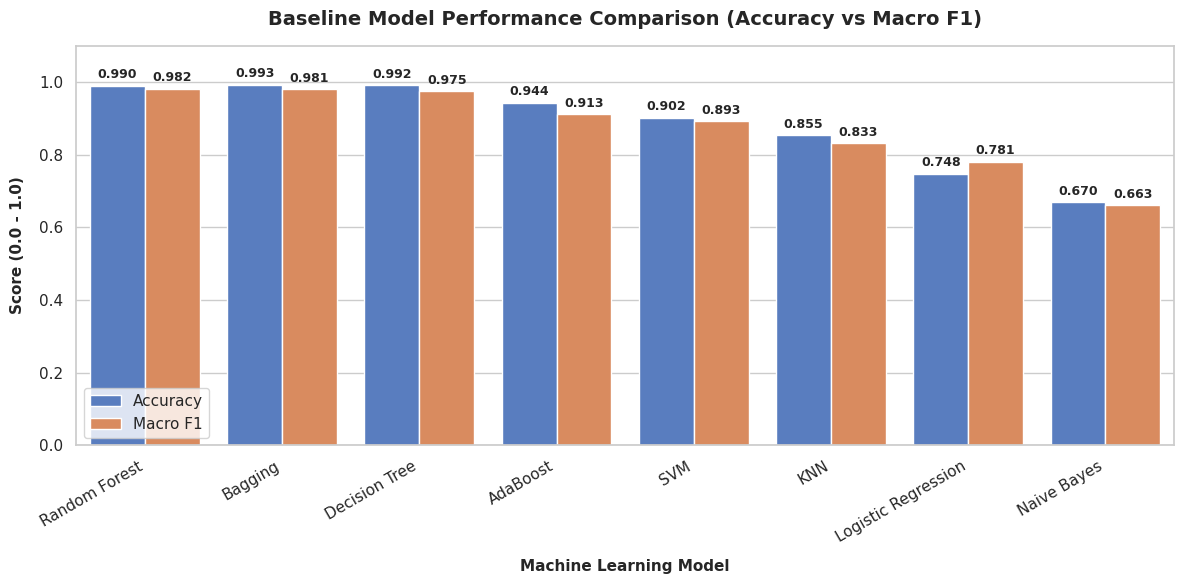

In [18]:
comp_base = pd.DataFrame(
    {
        name: {"Accuracy": v["Accuracy"], "Macro F1": v["Macro F1"]}
        for name, v in results_base.items()
    }
).T.sort_values("Macro F1", ascending=False)

print("\n" + "=" * 60)
print("Baseline Model Comparison:")
print("=" * 60)
print(comp_base.to_string())

# Plot Baseline Comparison
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(12, 6))

comp_long = comp_base.reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score"
)
comp_long.rename(columns={"index": "Model"}, inplace=True)

ax = sns.barplot(data=comp_long, x="Model", y="Score", hue="Metric")

plt.title("Baseline Model Performance Comparison (Accuracy vs Macro F1)", fontweight="bold", fontsize=14, pad=15)
plt.xlabel("Machine Learning Model", fontweight="bold", fontsize=11, labelpad=10)
plt.ylabel("Score (0.0 - 1.0)", fontweight="bold", fontsize=11, labelpad=10)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.1)
plt.legend(loc="lower left", frameon=True)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="semibold",
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()

---
## 10 · Feature Selection

We extract the feature importances from the baseline Random Forest model,
select the top 10 most important features, and trim our dataset to reduce noise.

In [19]:
rf_base = results_base["Random Forest"]["model"]
importances = pd.Series(rf_base.feature_importances_, index=feature_cols)
top10_features = importances.sort_values(ascending=False).head(10)

print("\n" + "=" * 60)
print("Top 10 Most Important Features (Random Forest):")
print("=" * 60)
print(top10_features)

# Get the indices of the top 10 features to slice the scaled numpy arrays
top10_indices = [feature_cols.index(col) for col in top10_features.index]

X_train_sc_reduced = X_train_sc[:, top10_indices]
X_test_sc_reduced = X_test_sc[:, top10_indices]

print(f"\n Reduced X_train shape: {X_train_sc_reduced.shape}")
print(f" Reduced X_test shape: {X_test_sc_reduced.shape}")


Top 10 Most Important Features (Random Forest):
PM2.5                            0.335386
Pollution_Index                  0.154933
PM10                             0.097503
AQI_Per_Capita                   0.087179
PM25_PM10_Ratio                  0.055418
Proximity_to_Industrial_Areas    0.033870
Temperature                      0.030867
Temp_Humidity                    0.029083
Population_Density               0.027438
NO2                              0.027350
dtype: float64

 Reduced X_train shape: (8670, 10)
 Reduced X_test shape: (2168, 10)


---
## 11 · Hyperparameter Tuning (Top 4 Models)

We select the top 4 best-performing baseline models and retrain them
on the REDUCED feature set using GridSearchCV.

In [20]:
from sklearn.model_selection import GridSearchCV

# Identify top 4 baseline models by Macro F1
top4_names = comp_base.index[:4].tolist()
print("\n" + "=" * 60)
print(f"Top 4 Models Selected for Tuning: {top4_names}")
print("=" * 60)

# Re-initialize the base models so they are fresh
models_to_tune = {name: models_to_train[name] for name in top4_names}

param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5, 10]
    },
    "Decision Tree": {
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 10],
        "weights": ["uniform", "distance"]
    },
    "Logistic Regression": {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "liblinear"]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1.0]
    },
    "Bagging": {
        "n_estimators": [50, 100, 200],
        "max_samples": [0.5, 0.8, 1.0],
        "max_features": [0.5, 0.8, 1.0]
    },
    "Naive Bayes": {
        "var_smoothing": [1e-9, 1e-8, 1e-7]
    }
}

results_tuned = {}
best_estimators = {}

for name, model in models_to_tune.items():
    print(f"\n Tuning {name} on REDUCED features...")
    print("-" * 50)
    
    grid = param_grids.get(name, {})
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    
    # Fit on REDUCED dataset
    grid_search.fit(X_train_sc_reduced, y_train)
    
    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model
    
    # Evaluate on REDUCED test dataset
    y_pred = best_model.predict(X_test_sc_reduced)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    
    results_tuned[name] = {"Tuned Accuracy": acc, "Tuned Macro F1": f1}
    
    print(f"Optimal Parameters: {grid_search.best_params_}")
    print(f"Test Accuracy: {acc:.4f}  |  Test Macro F1: {f1:.4f}")


Top 4 Models Selected for Tuning: ['Random Forest', 'Bagging', 'Decision Tree', 'AdaBoost']

 Tuning Random Forest on REDUCED features...
--------------------------------------------------
Fitting 3 folds for each of 27 candidates, totalling 81 fits


Optimal Parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
Test Accuracy: 0.9912  |  Test Macro F1: 0.9792

 Tuning Bagging on REDUCED features...
--------------------------------------------------
Fitting 3 folds for each of 27 candidates, totalling 81 fits


Optimal Parameters: {'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 200}
Test Accuracy: 0.9931  |  Test Macro F1: 0.9805

 Tuning Decision Tree on REDUCED features...
--------------------------------------------------
Fitting 3 folds for each of 9 candidates, totalling 27 fits


Optimal Parameters: {'max_depth': 10, 'min_samples_split': 2}
Test Accuracy: 0.9908  |  Test Macro F1: 0.9749

 Tuning AdaBoost on REDUCED features...
--------------------------------------------------
Fitting 3 folds for each of 9 candidates, totalling 27 fits


Optimal Parameters: {'learning_rate': 1.0, 'n_estimators': 200}
Test Accuracy: 0.9405  |  Test Macro F1: 0.9172


---
## 12 · Final Optimized Comparison


Final Tuned Model Comparison (Top 10 Features):
               Tuned Accuracy  Tuned Macro F1
Bagging              0.993081        0.980540
Random Forest        0.991236        0.979191
Decision Tree        0.990775        0.974931
AdaBoost             0.940498        0.917233


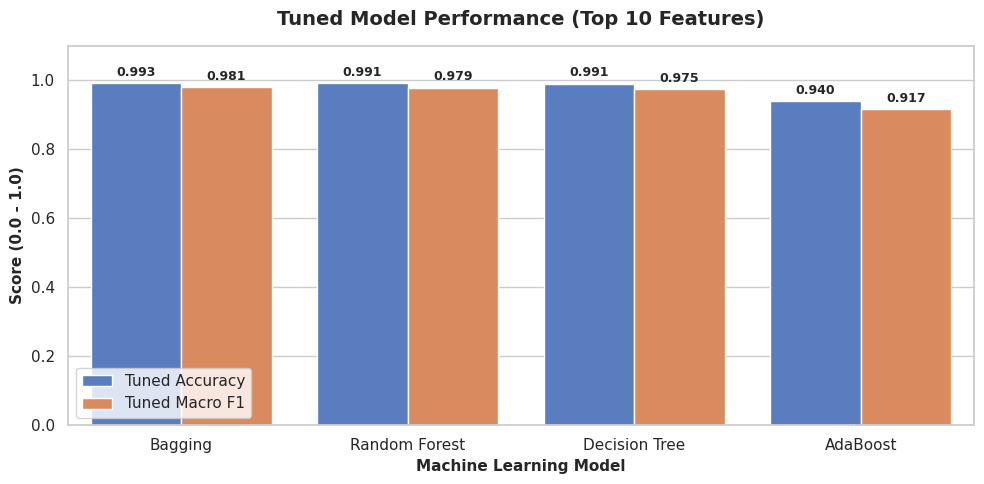

In [21]:
comp_tuned = pd.DataFrame(results_tuned).T.sort_values(by="Tuned Macro F1", ascending=False)

print("\n" + "=" * 60)
print("Final Tuned Model Comparison (Top 10 Features):")
print("=" * 60)
print(comp_tuned.to_string())

# Display final comparison graph
plt.figure(figsize=(10, 5))
comp_tuned_long = comp_tuned.reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score"
)
comp_tuned_long.rename(columns={"index": "Model"}, inplace=True)

ax2 = sns.barplot(data=comp_tuned_long, x="Model", y="Score", hue="Metric")
plt.title("Tuned Model Performance (Top 10 Features)", fontweight="bold", fontsize=14, pad=15)
plt.xlabel("Machine Learning Model", fontweight="bold", fontsize=11)
plt.ylabel("Score (0.0 - 1.0)", fontweight="bold", fontsize=11)
plt.ylim(0, 1.1)
plt.legend(loc="lower left", frameon=True)

for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="semibold",
            xytext=(0, 3),
            textcoords="offset points",
        )
plt.tight_layout()
plt.show()

---
## 13 · Summary

| Step | Status |
|------|--------|
| Dynamic Data Ingestion | DONE |
| Missing-Data Repair | DONE |
| Feature Engineering | DONE |
| Baseline Evaluation (8 Models) | DONE |
| Feature Selection (Top 10) | DONE |
| GridSearchCV (Top 4) | DONE |

Pipeline Complete!